
true m:  2.8668484906607237
true b:  -0.7999909312897096

est m:  2.9115764380308837
est b:  -0.8347780316360884

numpy m:  2.9115764380308846
numpy b:  -0.834778031636089

largest residual:  0.49862181571653674
smallest residual:  -0.4987383102530545
resMax point:  0.5300000000000002 1.2069792962368173
resMin point:  0.8100000000000005 1.0248605729158744


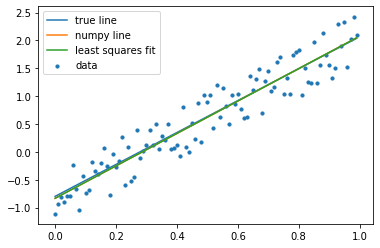

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import random

def myLeastSquares(x, y):
    
    n = len(x)

    sum_x = 0
    sum_y = 0
    sum_xy = 0
    sum_x2 = 0
    
    for i in range(n):
        sum_x += x[i]
        sum_y += y[i]
        sum_xy += x[i] * y[i]
        sum_x2 += x[i] * x[i]
    
    m = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x ** 2)
    b = (sum_y - m * sum_x) / n

    return m, b

# x_rand = np.random.rand(20)
# y_rand = np.random.rand(20)
# combined = list(zip(x_rand, y_rand))
# combined.sort()
# x_rand, y_rand = zip(*combined)

# m_custom, b_custom = myLeastSquares(x_rand, y_rand)

# A_rand = np.vstack([x_rand, np.ones(len(x_rand))]).T
# m_numpyRand, b_numpyRand = np.linalg.lstsq(A_rand, y_rand, rcond=None)[0]

# print("random data")
# print("custom m: ", m_custom)
# print("custom b: ", b_custom)
# print("numpy m: ", m_numpyRand)
# print("numpy b: ", b_numpyRand)

m_true = random.uniform(-5, 5)
b_true = random.uniform(-5, 5)

x = []
y = []

x_var = 0.0
while x_var <= 1.0:
    noise = random.uniform(-0.5, 0.5)
    y_var = m_true * x_var + b_true + noise
    x.append(x_var)
    y.append(y_var)
    x_var += 0.01
    
m_est, b_est = myLeastSquares(x, y)

A = np.vstack([x, np.ones(len(x))]).T
m_numpy, b_numpy = np.linalg.lstsq(A, y, rcond=None)[0]

print("\ntrue m: ", m_true)
print("true b: ", b_true)

print("\nest m: ", m_est)
print("est b: ", b_est)

print("\nnumpy m: ", m_numpy)
print("numpy b: ", b_numpy)

residuals = []

for i in range(len(x)):
    y_pred = m_est * x[i] + b_est
    residual = y[i] - y_pred
    residuals.append(residual)

resMax = max(residuals)
resMin = min(residuals)

y_trueLine =[]
y_estLine =[]
y_npLine =[]


for i in range(len(x)):
    y_trueLine.append(m_true * x[i] + b_true)
    y_estLine.append(m_est * x[i] + b_est)
    y_npLine.append(m_numpy * x[i] + b_numpy)

print("\nlargest residual: ", resMax)
print("smallest residual: ", resMin)

print("resMax point: ", 
      x[residuals.index(resMax)], y[residuals.index(resMax)])
print("resMin point: ", 
      x[residuals.index(resMin)], y[residuals.index(resMin)])

plt.scatter(x, y, s=10, label="data")    
plt.plot(x, y_trueLine, label='true line')
plt.plot(x, y_npLine, label='numpy line')
plt.plot(x, y_estLine, label='least squares fit')
plt.legend()
plt.show()

## The difference between my custom least squares line and the
## numpy version is quite small. This is because my function and
## numpy's lstsq function uses the same algorithm.